In [ ]:
import numpy as np

np.save('swmh_embeddings.npy', embeddings)

dimensionality reduction with UMAP

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


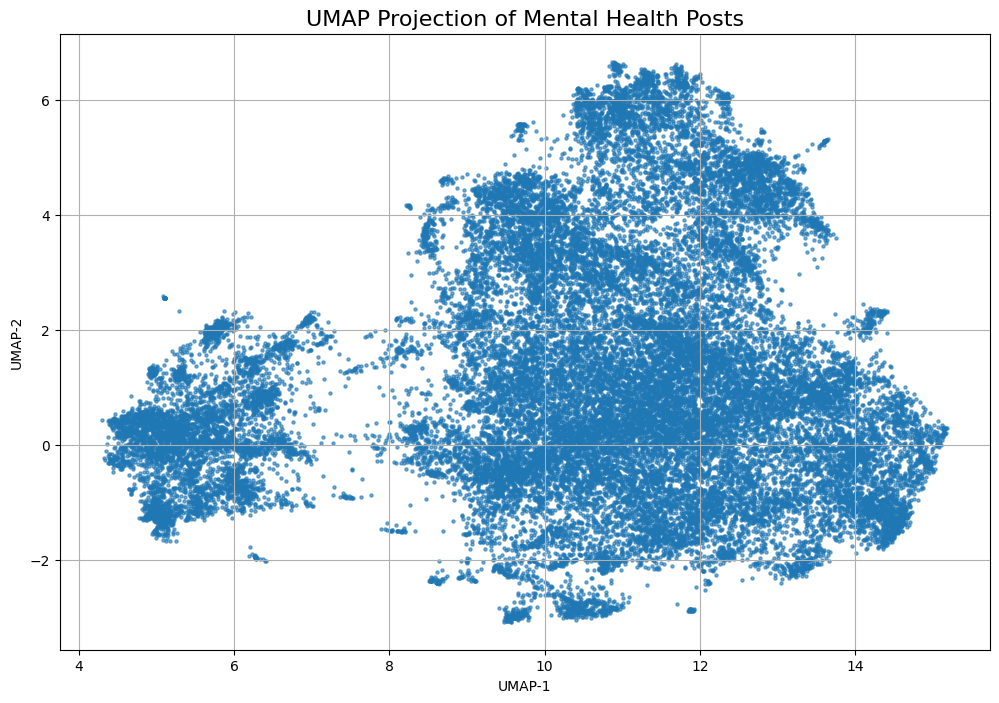

In [ ]:
# Install UMAP if not already installed
!pip install -q umap-learn

# Imports
import umap
import matplotlib.pyplot as plt

# Reduce dimensionality
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Plot the results
plt.figure(figsize=(12, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=5, alpha=0.6)
plt.title('UMAP Projection of Mental Health Posts', fontsize=16)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.grid(True)
plt.show()

hdbscan

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


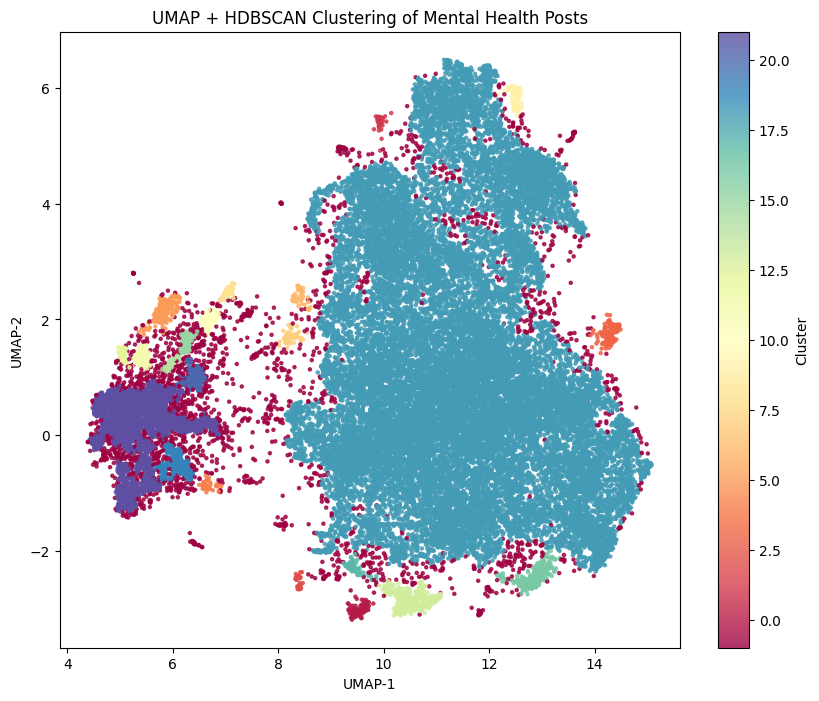

In [ ]:
import umap.umap_ as umap
import hdbscan
import matplotlib.pyplot as plt
import pandas as pd

# Dimensionality reduction
umap_model = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)

# Clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10)
cluster_labels = clusterer.fit_predict(umap_embeddings)

# Add labels to the dataframe
df['cluster'] = cluster_labels

# Plot UMAP with cluster labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
                      c=cluster_labels, cmap='Spectral', s=5, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP + HDBSCAN Clustering of Mental Health Posts')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.show()

understanding clusters

In [ ]:
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

# Fix for extracting plain text list
texts = list(dataset['train']['text'])

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(texts, show_progress_bar=True)

# UMAP dimensionality reduction
umap_model = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine')
umap_embeddings = umap_model.fit_transform(embeddings)

# HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric='euclidean', cluster_selection_method='eom')
cluster_labels = clusterer.fit_predict(umap_embeddings)

Batches:   0%|          | 0/1089 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import numpy as np
import pandas as pd

# Create DataFrame with text and cluster labels
df = pd.DataFrame({
    'text': dataset['train']['text'],
    'cluster': cluster_labels
})

# Remove noise points
df = df[df['cluster'] != -1]

# Group texts by cluster
cluster_texts = defaultdict(list)
for _, row in df.iterrows():
    cluster_texts[row['cluster']].append(row['text'])

# Function to extract top TF-IDF keywords
def extract_top_keywords(texts, top_n=10):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
    tfidf_matrix = vectorizer.fit_transform(texts)
    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    top_indices = np.argsort(mean_tfidf)[::-1][:top_n]
    return [terms[i] for i in top_indices]

# Display results for each cluster
for cluster_id, texts in cluster_texts.items():
    print(f"\n=== Cluster {cluster_id} ===")
    print(f"Number of posts: {len(texts)}")

    top_keywords = extract_top_keywords(texts)
    print(f"Top Keywords: {', '.join(top_keywords)}\n")

    print("Sample Post:")
    print(texts[0][:1000] + ("..." if len(texts[0]) > 1000 else ""))
    print("-" * 60)


=== Cluster 4 ===
Number of posts: 29516
Top Keywords: just, like, don, feel, want, ve, know, life, really, time

Sample Post:
wanting to skip or postpone my exam my exam is on saturday and i feel a massive urge to reschedule

i experience this often with major exams. *flashbacks to several years prior where i skipped all of my final exams and failed* 

i just dont feel ready i dont know im so tired and mentallly fried that i feel a few days might help. but a part of me thinks i should fight this urge and just tank it
------------------------------------------------------------

=== Cluster 1 ===
Number of posts: 4577
Top Keywords: deleted, don, want, feel, just, like, know, life, people, think

Sample Post:
I think this is the place to say this [deleted]
------------------------------------------------------------

=== Cluster 3 ===
Number of posts: 42
Top Keywords: coffee, caffeine, anxiety, drink, day, just, know, tea, does, feel

Sample Post:
Trying to quit caffeine bring me to a 

In [ ]:
from datasets import load_dataset
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

# Load dataset
dataset = load_dataset("AIMH/SWMH", split="train")
df = dataset.to_pandas()

# Clean text
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[\r\n]+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text.strip().lower()

df['cleaned_text'] = df['text'].apply(clean_text)
texts = df['cleaned_text'].tolist()

# Embedding
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(texts, show_progress_bar=True)

# Dimensionality reduction
umap_model = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)

# Clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric='euclidean', cluster_selection_method='eom')
cluster_labels = clusterer.fit_predict(umap_embeddings)

print("All set! Variables defined:\n- texts\n- umap_embeddings\n- cluster_labels")

Batches:   0%|          | 0/1089 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


All set! Variables defined:
- texts
- umap_embeddings
- cluster_labels


/tmp/ipython-input-887897812.py:18: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


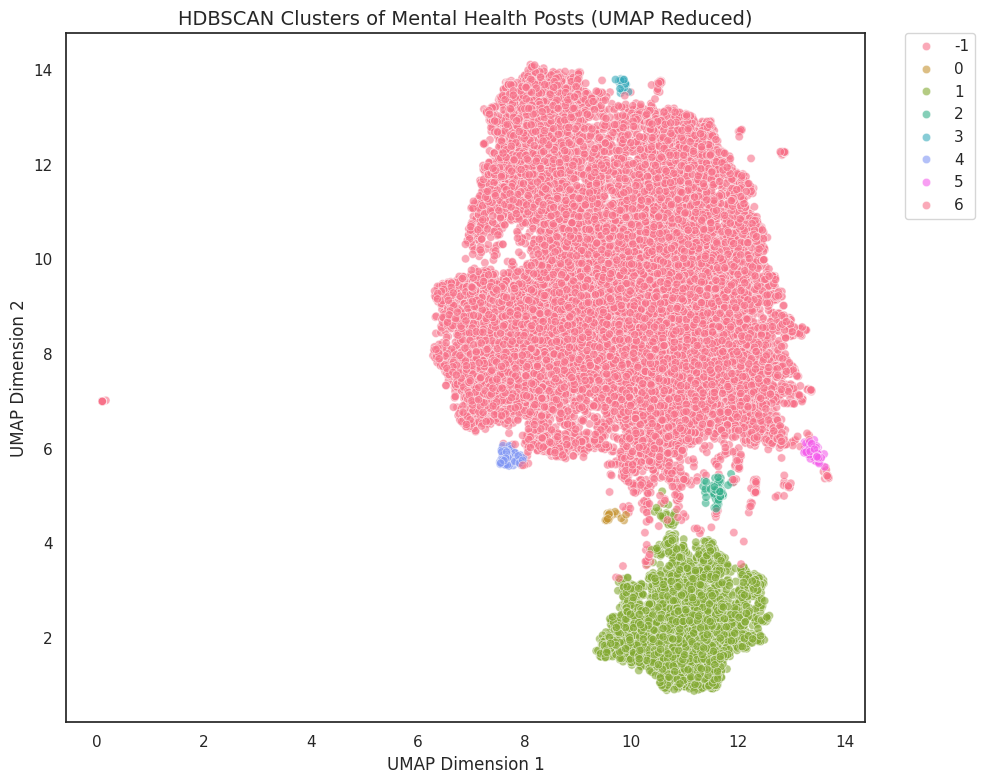

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up DataFrame for plotting
plot_df = pd.DataFrame({
    'x': umap_embeddings[:, 0],
    'y': umap_embeddings[:, 1],
    'cluster': cluster_labels
})

# Set -1 (noise points) as a separate color
palette = sns.color_palette("husl", len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))
sns.set(style='white', rc={'figure.figsize':(10,8)})

# Plot
plt.figure()
sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    data=plot_df,
    palette=palette,
    legend='full',
    alpha=0.6
)

plt.title('HDBSCAN Clusters of Mental Health Posts (UMAP Reduced)', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q sentence-transformers umap-learn hdbscan datasets

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
dataset = load_dataset("AIMH/SWMH", split="train")
data = pd.DataFrame(dataset)
texts = data["text"].tolist()  # <-- FIXED here

# 2. SBERT embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(texts, show_progress_bar=True, batch_size=64)

# 3. UMAP reduction
umap_model = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)

# 4. HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, metric='euclidean', cluster_selection_method='eom')
cluster_labels = clusterer.fit_predict(umap_embeddings)

# 5. Save embeddings and labels
np.save("sbert_umap_embeddings.npy", umap_embeddings)
np.save("cluster_labels.npy", cluster_labels)

# 6. Attach to DataFrame
data["cluster"] = cluster_labels

# 7. Quick cluster summary
for label in sorted(set(cluster_labels)):
    subset = data[data["cluster"] == label]
    print(f"\n=== Cluster {label} ===")
    print(f"Number of posts: {len(subset)}")
    top_words = pd.Series(" ".join(subset["text"]).lower().split()).value_counts().head(10)
    print(f"Top Keywords: {', '.join(top_words.index)}")
    print("\nSample Post:\n" + subset['text'].iloc[0])
    print("-" * 60)

Batches:   0%|          | 0/545 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



=== Cluster -1 ===
Number of posts: 303
Top Keywords: i, to, the, and, a, of, my, in, it, for

Sample Post:
ANYONE here ever tried r-TMS (repeated Transcranial Magnetic Stimulation) to treat BPD (any type)? Clarification: BPD—&gt;BIPOLAR disorder I mean, sorry for any confusion! 
------------------------------------------------------------

=== Cluster 0 ===
Number of posts: 4596
Top Keywords: i, [deleted], to, my, and, a, the, of, is, me

Sample Post:
I think this is the place to say this [deleted]
------------------------------------------------------------

=== Cluster 1 ===
Number of posts: 29924
Top Keywords: i, to, and, the, a, my, of, that, in, it

Sample Post:
wanting to skip or postpone my exam my exam is on saturday and i feel a massive urge to reschedule

i experience this often with major exams. *flashbacks to several years prior where i skipped all of my final exams and failed* 

i just dont feel ready i dont know im so tired and mentallly fried that i feel a few days mig

In [ ]:
# Show 5 examples from each cluster
for label in sorted(data["cluster"].unique()):
    print(f"\nCluster {label} — Sample posts:")
    samples = data[data["cluster"] == label]["text"].head(5).tolist()
    for i, post in enumerate(samples):
        print(f"{i+1}. {post[:300]}...\n")


Cluster -1 — Sample posts:
1. ANYONE here ever tried r-TMS (repeated Transcranial Magnetic Stimulation) to treat BPD (any type)? Clarification: BPD—&gt;BIPOLAR disorder I mean, sorry for any confusion! ...

2. I just bought a "love doll" for myself. I've never made a purchase like that, and I wonder if it means I'm weird. I don't want it for sex (well, not *just* for sex), but for physical touch, too.  I'm by myself all the time and just having something to cuddle against would be nice.

Is that weird or ...

3. Do you ever get this amazing happy feeling for like 15 seconds and then you go back to wanting to jump under a train? [deleted]...

4. Does anyone else feel depressed about the end of net neutrality? [deleted]...

5. Depressed after Dates Has anyone had success dealing with depression after dates? Starting with my last relationship, I have had some tremendous anxiety and depression tied into my dating life. 
With the current girl, I sometimes come home from a date and start fe

extract top keywords

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Ensure all text is string
data["text"] = data["text"].astype(str)

# Create TF-IDF matrix
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = vectorizer.fit_transform(data["text"])
feature_names = vectorizer.get_feature_names_out()

# Print top N terms per cluster
N = 15
for label in sorted(data["cluster"].unique()):
    cluster_indices = np.where(data["cluster"] == label)[0]
    cluster_tfidf = X_tfidf[cluster_indices].mean(axis=0)
    top_indices = np.argsort(cluster_tfidf.A1)[::-1][:N]
    top_terms = [feature_names[i] for i in top_indices]
    print(f"\n🧠 Cluster {label}: Top {N} terms:\n", ", ".join(top_terms))


🧠 Cluster -1: Top 15 terms:
 deleted, hug, just, want, stories, like, feel, need, neutrality, anxiety, sunday, don, net, week, mood

🧠 Cluster 0: Top 15 terms:
 deleted, don, want, feel, just, life, like, know, removed, people, kill, depression, think, need, help

🧠 Cluster 1: Top 15 terms:
 just, like, don, feel, want, ve, know, life, really, time, people, anxiety, going, think, help



🔹 Cluster -1:
Top Keywords: just, like, fuck, don, want, feel, people, know, anxiety, ve

🔹 Cluster 0:
Top Keywords: deleted, just, want, don, feel, like, life, know, people, think

🔹 Cluster 1:
Top Keywords: just, like, don, feel, know, ve, want, time, life, really


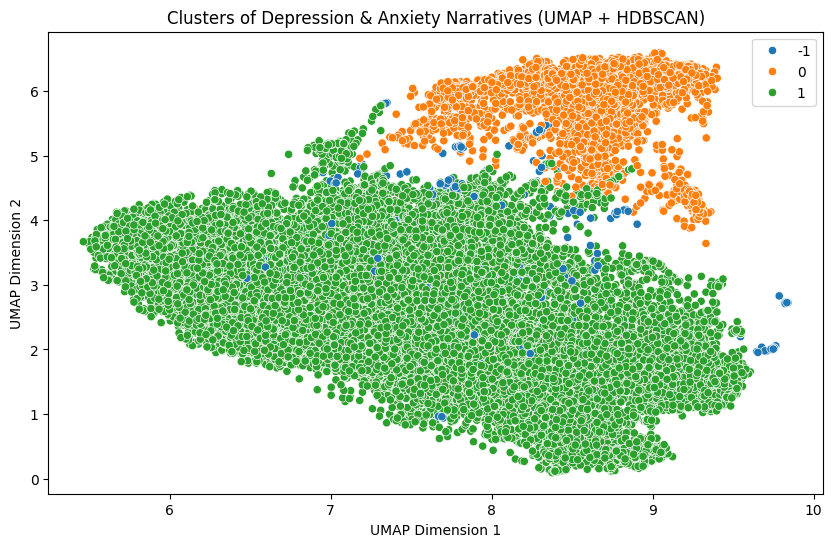

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and prepare DataFrame
dataset = load_dataset("AIMH/SWMH", split="train")
data = dataset.to_pandas()
data["text"] = data["text"].astype(str)

# Load saved embeddings and cluster labels
umap_embeddings = np.load("sbert_umap_embeddings.npy")
cluster_labels = np.load("cluster_labels.npy")

# Add cluster labels to DataFrame
data["cluster"] = cluster_labels

# Create a DataFrame to group text by cluster
grouped = data.groupby("cluster")["text"].apply(lambda x: " ".join(x)).reset_index()

# Compute TF-IDF to get top keywords per cluster
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(grouped["text"])
terms = vectorizer.get_feature_names_out()

# Extract top keywords per cluster
def get_top_keywords(tfidf_vector, terms, top_n=10):
    sorted_indices = tfidf_vector.toarray().flatten().argsort()[::-1]
    return [terms[i] for i in sorted_indices[:top_n]]

grouped["top_keywords"] = [
    get_top_keywords(tfidf_matrix[i], terms) for i in range(tfidf_matrix.shape[0])
]

# Show top keywords per cluster
for i, row in grouped.iterrows():
    print(f"\n🔹 Cluster {row['cluster']}:")
    print("Top Keywords:", ", ".join(row["top_keywords"]))

# Optional: visualize the clusters using the UMAP embeddings
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=umap_embeddings[:, 0],
    y=umap_embeddings[:, 1],
    hue=cluster_labels,
    palette="tab10",
    legend="full"
)
plt.title("Clusters of Depression & Anxiety Narratives (UMAP + HDBSCAN)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

/tmp/ipython-input-1036324647.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = data.groupby("cluster").apply(lambda x: x.sample(n=min(100, len(x)), random_state=42)).reset_index(drop=True)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]


📊 Emotion Distribution per Cluster (Normalized):


emotion,anger,joy,optimism,sadness
cluster,,,,
-1,0.17,0.16,0.12,0.55
0,0.15,0.04,0.00,0.81
1,0.18,0.07,0.03,0.72


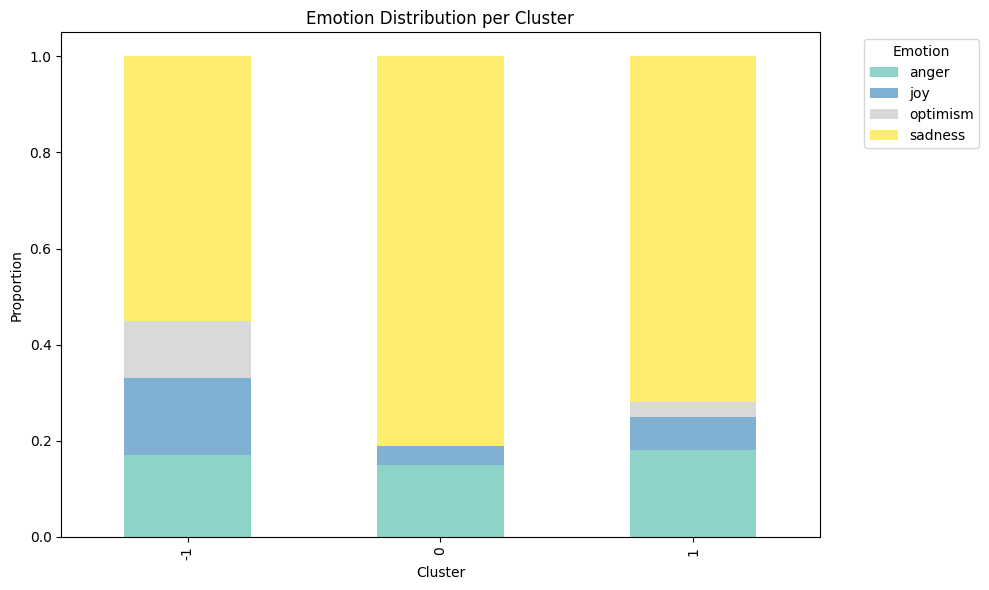


🧠 Label Distribution per Cluster (Normalized):


label,self.Anxiety,self.SuicideWatch,self.bipolar,self.depression,self.offmychest
cluster,,,,,
-1,0.168317,0.105611,0.254125,0.310231,0.161716
0,0.132289,0.199304,0.039382,0.401871,0.227154
1,0.183030,0.187208,0.156196,0.334147,0.139420


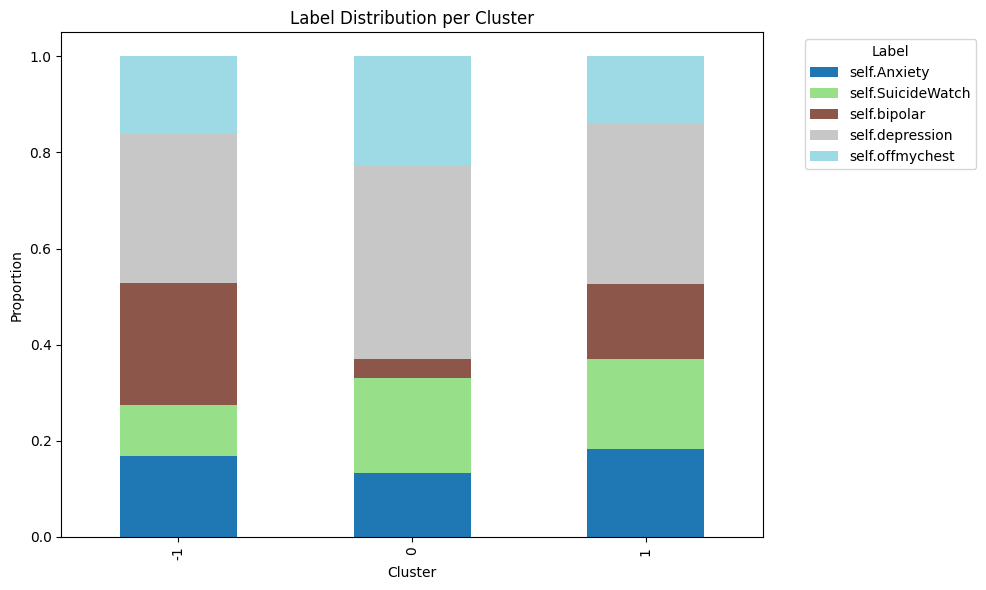

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Load emotion classifier (RoBERTa fine-tuned on emotion labels)
model_name = "cardiffnlp/twitter-roberta-base-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Define emotion labels based on the model's output
emotion_labels = ['anger', 'joy', 'optimism', 'sadness']

# Function to get dominant emotion from text
def get_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=1)
    top = torch.argmax(probs, dim=1).item()
    return emotion_labels[top]

# Apply emotion detection on a sample of each cluster (for speed)
sampled = data.groupby("cluster").apply(lambda x: x.sample(n=min(100, len(x)), random_state=42)).reset_index(drop=True)
sampled["emotion"] = sampled["text"].apply(get_emotion)

# Get most common emotion per cluster
emotion_summary = sampled.groupby("cluster")["emotion"].value_counts().unstack().fillna(0)
emotion_summary = emotion_summary.div(emotion_summary.sum(axis=1), axis=0)  # Normalize

print("\n📊 Emotion Distribution per Cluster (Normalized):")
display(emotion_summary)

# Plot emotion distribution
emotion_summary.plot(kind="bar", stacked=True, figsize=(10,6), colormap="Set3")
plt.title("Emotion Distribution per Cluster")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Optional: check label distribution if 'label' column is meaningful
if "label" in data.columns:
    label_dist = data.groupby("cluster")["label"].value_counts().unstack().fillna(0)
    label_dist = label_dist.div(label_dist.sum(axis=1), axis=0)
    print("\n🧠 Label Distribution per Cluster (Normalized):")
    display(label_dist)

    # Plot label distribution
    label_dist.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab20")
    plt.title("Label Distribution per Cluster")
    plt.ylabel("Proportion")
    plt.xlabel("Cluster")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
from transformers import pipeline
from tqdm import tqdm

# Load emotion classifier pipeline
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    tokenizer="j-hartmann/emotion-english-distilroberta-base",
    device=0,
    truncation=True,
    max_length=512,
    top_k=1  # returns list of top prediction(s)
)

tqdm.pandas()

# Fix for nested output (e.g., [[{'label': 'joy', 'score': 0.95}]])
def predict_emotion(text):
    result = emotion_classifier(text)
    return result[0][0]['label']  # Double indexing: outer [0] for list, inner [0] for top prediction

# Apply to your DataFrame
df["emotions"] = df["text"].progress_apply(predict_emotion)

Device set to use cuda:0
  0%|          | 0/34823 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 34823/34823 [05:21<00:00, 108.43it/s]


emotion distribution per cluster


/tmp/ipython-input-1895203905.py:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


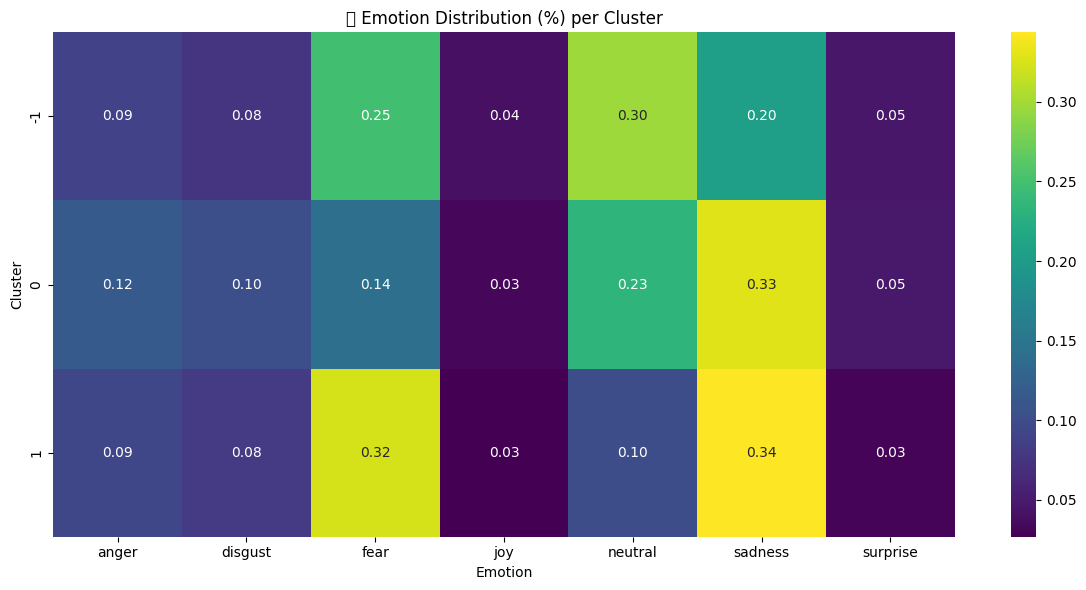

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of emotions per cluster
emotion_counts = df.groupby(["cluster", "emotions"]).size().unstack(fill_value=0)

# Normalize for percentage view (optional)
emotion_percent = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

# Plot: Heatmap of emotion % per cluster
plt.figure(figsize=(12, 6))
sns.heatmap(emotion_percent, annot=True, fmt=".2f", cmap="viridis")
plt.title("📊 Emotion Distribution (%) per Cluster")
plt.xlabel("Emotion")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

 Top Emotions in Each Cluster

In [ ]:
# Top emotion in each cluster
top_emotions = df.groupby("cluster")["emotions"].agg(lambda x: x.value_counts().idxmax())

print("🔍 Dominant Emotion per Cluster:\n")
print(top_emotions)

🔍 Dominant Emotion per Cluster:

cluster
-1    neutral
 0    sadness
 1    sadness
Name: emotions, dtype: object


cluster narratives

In [ ]:
# Sample 3 texts from each cluster
for cluster_id in sorted(df["cluster"].unique()):
    print(f"\n🌀 Cluster {cluster_id} - Top Emotion: {top_emotions[cluster_id]}")
    samples = df[df["cluster"] == cluster_id]["text"].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"\n  ➤ Sample {i}:\n{text[:500]}...\n")  # Truncated for readability


🌀 Cluster -1 - Top Emotion: neutral

  ➤ Sample 1:
Thoughts about evolution Hi,

I wrote a text about depression, anxiety and stress and really want to share with you. I hope it brings peace to your heart and mind.

https://medium.com/@vibaro/theres-a-ship-at-our-horizon-9d5267e3daed

I want to hear you, let's talk about it....


  ➤ Sample 2:
Small Victory Saturday 11.11.17 / Goal Setting Sunday 11.12.17 Sorry I didn't get yesterday's post up, I had a date that went really well and I didn't expect her to stay over, so I didn't get to post before bed. What did you accomplish this last week and what do you want to achieve this week?...


  ➤ Sample 3:
Starting the New Year off with being in a fight with the husband. Yippie I am also 18 weeks pregnant, so I can't drink the night away. If you are out there drinking responsibly, have a shot/drink for me. 

Be safe everyone!...


🌀 Cluster 0 - Top Emotion: sadness

  ➤ Sample 1:
I wanna kill myself because I can’t find someone to be with. 

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt

# Optional: adjust pandas display
pd.set_option("display.max_colwidth", 500)

# ---- SETTINGS ----
top_k_ngrams = 10
sample_texts_per_cluster = 3
ngram_size = 2

# ---- EMOTION DISTRIBUTION ----
print("🔹 Emotion distribution per cluster:\n")
emotion_dist = df.groupby("cluster")["emotions"].value_counts(normalize=True).unstack().fillna(0)
display(emotion_dist)

# ---- N-GRAM + SAMPLE TEXT + SUMMARY ----
print("\n🔹 Thematic breakdown by cluster:\n")

def get_top_ngrams(texts, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')
    X = vec.fit_transform(texts)
    freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).A1)
    return sorted(freqs, key=lambda x: -x[1])[:top_k]

cluster_ids = sorted(df["cluster"].unique())
thematic_summary = {}

for cid in cluster_ids:
    cluster_texts = df[df["cluster"] == cid]["text"]
    cluster_emotions = df[df["cluster"] == cid]["emotions"]

    # Top bigrams
    top_ngrams = get_top_ngrams(cluster_texts.tolist(), n=ngram_size, top_k=top_k_ngrams)

    # Sample texts
    samples = cluster_texts.sample(sample_texts_per_cluster, random_state=42).tolist()

    # Create summary
    summary = {
        "Top Emotions": Counter(cluster_emotions).most_common(3),
        "Top Bigrams": top_ngrams,
        "Sample Texts": samples
    }

    thematic_summary[cid] = summary

    # Print summary
    print(f"\n--- Cluster {cid} ---")
    print(f"🧠 Top Emotions: {summary['Top Emotions']}")
    print(f"📝 Top Bigrams: {[ngram for ngram, freq in summary['Top Bigrams']]}")
    print(f"📋 Sample Texts:")
    for i, txt in enumerate(summary["Sample Texts"], 1):
        print(f"  {i}. {txt[:300].strip()}...\n")

# Optional: save summary to a text/JSON file
# import json
# with open("thematic_cluster_summary.json", "w") as f:
#     json.dump(thematic_summary, f, indent=2)

🔹 Emotion distribution per cluster:



emotions,anger,disgust,fear,joy,neutral,sadness,surprise
cluster,,,,,,,
-1,0.089109,0.075908,0.247525,0.039604,0.297030,0.204620,0.046205
0,0.115100,0.103568,0.140992,0.032855,0.232376,0.328111,0.046997
1,0.094339,0.081506,0.322550,0.026935,0.100488,0.343570,0.030611



🔹 Thematic breakdown by cluster:


--- Cluster -1 ---
🧠 Top Emotions: [('neutral', 90), ('fear', 75), ('sadness', 62)]
📝 Top Bigrams: ['fuck fuck', 'net neutrality', 'org votes', 'votesmart org', 'http votesmart', 'feel like', 'don want', 'fearless fridays', 'don know', 'feel free']
📋 Sample Texts:
  1. Thoughts about evolution Hi,

I wrote a text about depression, anxiety and stress and really want to share with you. I hope it brings peace to your heart and mind.

https://medium.com/@vibaro/theres-a-ship-at-our-horizon-9d5267e3daed

I want to hear you, let's talk about it....

  2. Small Victory Saturday 11.11.17 / Goal Setting Sunday 11.12.17 Sorry I didn't get yesterday's post up, I had a date that went really well and I didn't expect her to stay over, so I didn't get to post before bed. What did you accomplish this last week and what do you want to achieve this week?...

  3. Starting the New Year off with being in a fight with the husband. Yippie I am also 18 weeks pregnant, so I

In [ ]:
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Set the cluster number you want to inspect
cluster_id = 1  # change this to 2, 3, etc. for other clusters

# Filter DataFrame to the selected cluster
cluster_df = df[df['cluster'] == cluster_id]

# --- Top Emotions ---
top_emotions = Counter(cluster_df['emotions']).most_common(10)

# --- Top Bigrams ---
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=1000)
X = vectorizer.fit_transform(cluster_df['text'])
bigrams = vectorizer.get_feature_names_out()
bigram_counts = X.sum(axis=0).A1
bigram_freq = sorted(zip(bigrams, bigram_counts), key=lambda x: x[1], reverse=True)[:10]

# --- Sample Texts ---
sample_texts = cluster_df['text'].sample(3, random_state=42).tolist()

# --- Display ---
print(f"--- Cluster {cluster_id} ---")
print(f"🧠 Top Emotions: {top_emotions}")
print(f"📝 Top Bigrams: {[b[0] for b in bigram_freq]}")
print("📋 Sample Texts:")
for i, text in enumerate(sample_texts, 1):
    print(f"{i}. {text[:300]}...\n")

--- Cluster 1 ---
🧠 Top Emotions: [('sadness', 10281), ('fear', 9652), ('neutral', 3007), ('anger', 2823), ('disgust', 2439), ('surprise', 916), ('joy', 806)]
📝 Top Bigrams: ['feel like', 'don know', 'don want', 'just want', 'feels like', 'just don', 'don think', 'high school', 'felt like', 'just feel']
📋 Sample Texts:
1. I think I have rheumatoid arthritis. I'm 19. I was already depressed. I had resolved to make it for at least as long as my parents were living though. Now that seems impossible. I'm going to be a burden now and live in pain. One of the things keeping me going before was a lot of exercise and lifting...

2. I have dreams and ambitions yet I can not find the motivation to make them happen Sometimes it feels like it might be easier to live a life as a normal 9-5 zombie, plodding along to a job I despise deep down every day. I suppose in ways it would be nice to have a simple life, nothing too mad but to ...

3. Does anyone else give themselves excuses as to why you can't

In [ ]:
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Set the cluster number you want to inspect
cluster_id = 0  # change this to 2, 3, etc. for other clusters

# Filter DataFrame to the selected cluster
cluster_df = df[df['cluster'] == cluster_id]

# --- Top Emotions ---
top_emotions = Counter(cluster_df['emotions']).most_common(10)

# --- Top Bigrams ---
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=1000)
X = vectorizer.fit_transform(cluster_df['text'])
bigrams = vectorizer.get_feature_names_out()
bigram_counts = X.sum(axis=0).A1
bigram_freq = sorted(zip(bigrams, bigram_counts), key=lambda x: x[1], reverse=True)[:10]

# --- Sample Texts ---
sample_texts = cluster_df['text'].sample(3, random_state=42).tolist()

# --- Display ---
print(f"--- Cluster {cluster_id} ---")
print(f"🧠 Top Emotions: {top_emotions}")
print(f"📝 Top Bigrams: {[b[0] for b in bigram_freq]}")
print("📋 Sample Texts:")
for i, text in enumerate(sample_texts, 1):
    print(f"{i}. {text[:300]}...\n")

--- Cluster 0 ---
🧠 Top Emotions: [('sadness', 1508), ('neutral', 1068), ('fear', 648), ('anger', 529), ('disgust', 476), ('surprise', 216), ('joy', 151)]
📝 Top Bigrams: ['feel like', 'don know', 'want die', 'die want', 'don want', 'life deleted', 'help deleted', 'anymore deleted', 'know deleted', 'kill deleted']
📋 Sample Texts:
1. I wanna kill myself because I can’t find someone to be with. [deleted]...

2. Everyday that passes reinforces the idea that killing myself is the right choice. [deleted]...

3. Put the belt up, tried twice but I couldn’t go through with it [deleted]...



In [ ]:
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Set the cluster number you want to inspect
cluster_id = -1  # change this to 2, 3, etc. for other clusters

# Filter DataFrame to the selected cluster
cluster_df = df[df['cluster'] == cluster_id]

# --- Top Emotions ---
top_emotions = Counter(cluster_df['emotions']).most_common(10)

# --- Top Bigrams ---
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=1000)
X = vectorizer.fit_transform(cluster_df['text'])
bigrams = vectorizer.get_feature_names_out()
bigram_counts = X.sum(axis=0).A1
bigram_freq = sorted(zip(bigrams, bigram_counts), key=lambda x: x[1], reverse=True)[:10]

# --- Sample Texts ---
sample_texts = cluster_df['text'].sample(3, random_state=42).tolist()

# --- Display ---
print(f"--- Cluster {cluster_id} ---")
print(f"🧠 Top Emotions: {top_emotions}")
print(f"📝 Top Bigrams: {[b[0] for b in bigram_freq]}")
print("📋 Sample Texts:")
for i, text in enumerate(sample_texts, 1):
    print(f"{i}. {text[:300]}...\n")

--- Cluster -1 ---
🧠 Top Emotions: [('neutral', 90), ('fear', 75), ('sadness', 62), ('anger', 27), ('disgust', 23), ('surprise', 14), ('joy', 12)]
📝 Top Bigrams: ['fuck fuck', 'net neutrality', 'org votes', 'votesmart org', 'http votesmart', 'feel like', 'don want', 'fearless fridays', 'don know', 'feel free']
📋 Sample Texts:
1. Thoughts about evolution Hi,

I wrote a text about depression, anxiety and stress and really want to share with you. I hope it brings peace to your heart and mind.

https://medium.com/@vibaro/theres-a-ship-at-our-horizon-9d5267e3daed

I want to hear you, let's talk about it....

2. Small Victory Saturday 11.11.17 / Goal Setting Sunday 11.12.17 Sorry I didn't get yesterday's post up, I had a date that went really well and I didn't expect her to stay over, so I didn't get to post before bed. What did you accomplish this last week and what do you want to achieve this week?...

3. Starting the New Year off with being in a fight with the husband. Yippie I am also 18

📐 Silhouette Score: 0.4613
📉 Davies-Bouldin Index: 0.6587

📊 Cluster Sizes:
Cluster
-1      303
 0     4596
 1    29924
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipython-input-1072820439.py:48: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


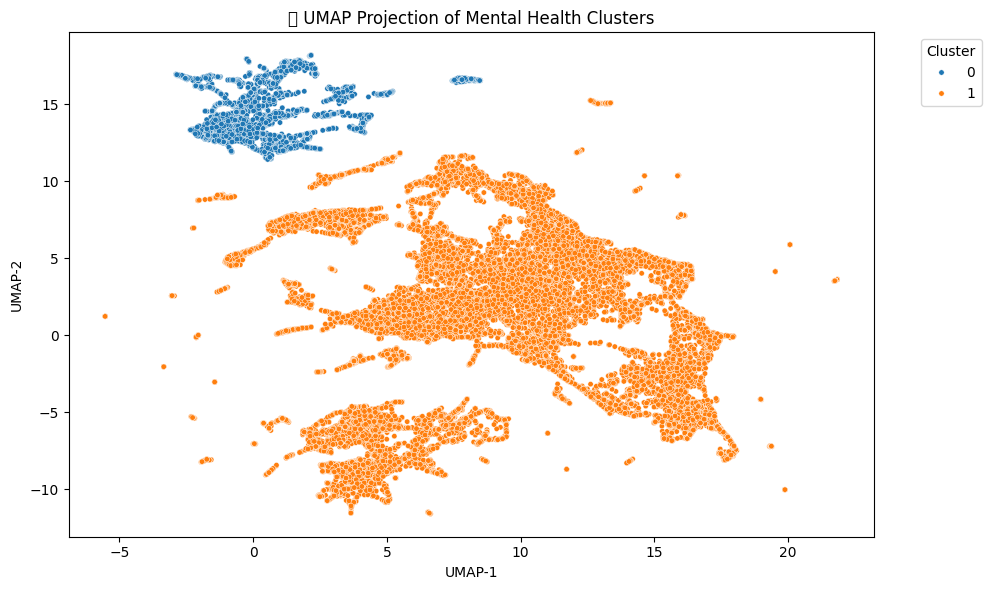

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# Step 1: Load Embeddings and Labels
embeddings = np.load('sbert_umap_embeddings.npy')  # (N, D)
cluster_labels = np.load('cluster_labels.npy')     # (N,)

# Step 2: Filter out noise if using HDBSCAN
# (Only use labels >= 0 for evaluation)
mask = cluster_labels >= 0
filtered_embeddings = embeddings[mask]
filtered_labels = cluster_labels[mask]

# Step 3: Compute Evaluation Metrics
sil_score = silhouette_score(filtered_embeddings, filtered_labels)
db_index = davies_bouldin_score(filtered_embeddings, filtered_labels)

print(f"📐 Silhouette Score: {sil_score:.4f}")
print(f"📉 Davies-Bouldin Index: {db_index:.4f}")

# Step 4: Cluster Size Summary
cluster_df = pd.DataFrame({'Cluster': cluster_labels})
cluster_counts = cluster_df['Cluster'].value_counts().sort_index()
print("\n📊 Cluster Sizes:")
print(cluster_counts)

# Step 5: UMAP 2D Visualization
umap_2d = umap.UMAP(n_components=2, random_state=42)
umap_2d_embeddings = umap_2d.fit_transform(filtered_embeddings)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=umap_2d_embeddings[:, 0],
    y=umap_2d_embeddings[:, 1],
    hue=filtered_labels,
    palette='tab10',
    s=15,
    legend='full'
)
plt.title("🧠 UMAP Projection of Mental Health Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()